In [2]:
import matplotlib.pyplot as plt
from src.data_loader import load_binance_data_csv
from src.features import build_features, FEATURE_COLUMNS, add_returns, add_moving_averages
from src.validation import chronological_split, random_strategy_baseline, significance
from src.models import make_logreg, make_gradient_boosting, train_and_predict, arima_signal, fit_garch_volatility
from src.backtest import run_ml_strategy, run_ma_strategy, run_agent_strategy
from src.metrics import summary
from src.agents import TradingAgent

import pandas as pd

In [3]:
df = load_binance_data_csv()

# 2. Features
df = add_returns(df)
df = add_moving_averages(df, fast=50, slow=200)

df = run_ma_strategy(df, fee=0.001)

metrics = pd.DataFrame({
    "MA50/200":   summary(df["strategy_equity"], df["strategy_return"]),
    "Buy & Hold": summary(df["market_equity"],  df["market_return"]),
})
metrics

,MA50/200,Buy & Hold
ROI %,86.13,64.71
Sharpe,0.58,0.48
Sortino,0.66,0.68
Calmar,0.41,0.18
Max Drawdown %,-37.25,-66.73
Win Rate %,26.23,49.41


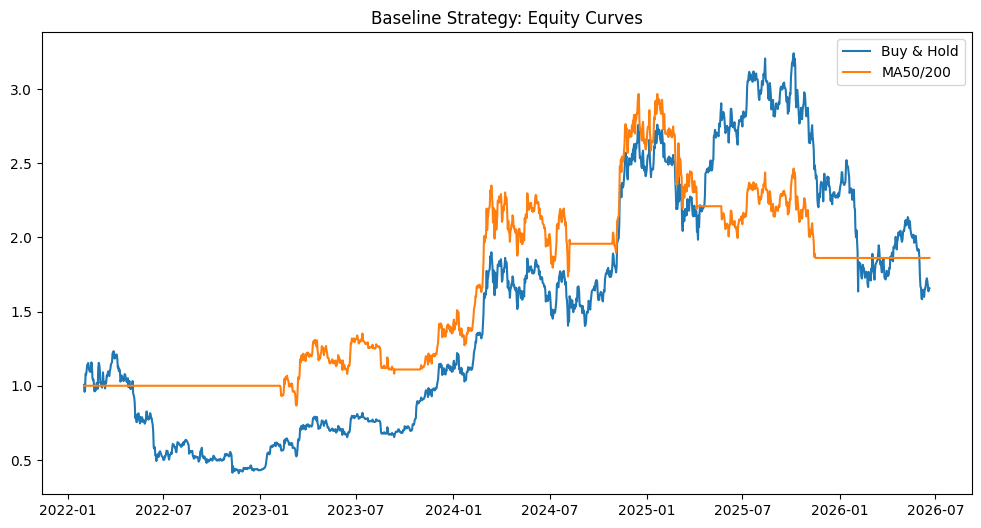

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df["timestamp"], df["market_equity"], label="Buy & Hold")
plt.plot(df["timestamp"], df["strategy_equity"], label="MA50/200")
plt.legend()
plt.title("Baseline Strategy: Equity Curves")
plt.show()

In [5]:
# 1. Данные + признаки
df = load_binance_data_csv()
df = build_features(df)

# 2. Хронологический split (без перемешивания!)
train, test = chronological_split(df, train_ratio=0.7)

# 3. Логистическая регрессия (бенчмарк)
test_lr, _ = train_and_predict(make_logreg(), train, test, FEATURE_COLUMNS)
bt_lr = run_ml_strategy(test_lr)

# 4. Градиентный бустинг
test_gb, _ = train_and_predict(make_gradient_boosting(), train, test, FEATURE_COLUMNS)
bt_gb = run_ml_strategy(test_gb)

# 5. Сравнительная таблица (на ОДНОМ тестовом периоде)
results = pd.DataFrame({
    "LogReg":           summary(bt_lr["strategy_equity"], bt_lr["strategy_return"]),
    "GradBoosting":     summary(bt_gb["strategy_equity"], bt_gb["strategy_return"]),
    "Buy & Hold (test)": summary(bt_gb["market_equity"], bt_gb["market_return"]),
})
results

,LogReg,GradBoosting,Buy & Hold (test)
ROI %,-25.93,-61.11,-24.76
Sharpe,-0.53,-2.02,-0.34
Sortino,-0.49,-2.09,-0.48
Calmar,-0.42,-0.74,-0.38
Max Drawdown %,-48.62,-69.11,-51.16
Win Rate %,18.58,17.75,49.27


In [6]:
strat_roi = (bt_gb["strategy_equity"].iloc[-1] - 1) * 100
random_rois = random_strategy_baseline(bt_gb)
pct, pval = significance(strat_roi, random_rois)
print(f"Стратегия обогнала {pct:.1f}% случайных стратегий (p-value ≈ {pval:.3f})")

Стратегия обогнала 2.2% случайных стратегий (p-value ≈ 0.978)


In [7]:
print("Доля 'вверх' в train target:", train["target"].mean().round(3))
print("Доля 'вверх' в test target:", test["target"].mean().round(3))
print("Доля предсказаний '1' (LogReg):", test_lr["pred"].mean().round(3))
print("Доля предсказаний '1' (GB):", test_gb["pred"].mean().round(3))

Доля 'вверх' в train target: 0.494
Доля 'вверх' в test target: 0.493
Доля предсказаний '1' (LogReg): 0.399
Доля предсказаний '1' (GB): 0.437


<Axes: title={'center': 'Feature Importance (GB)'}>

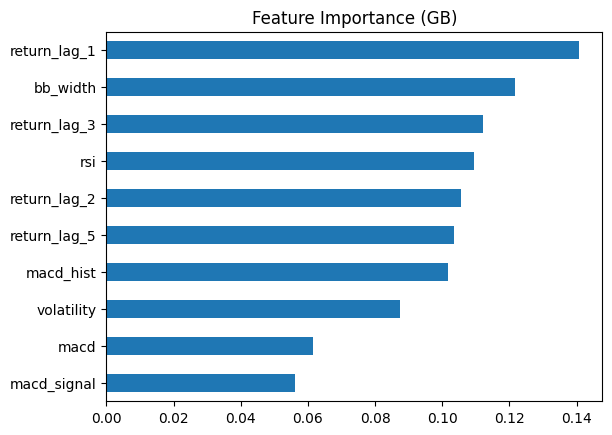

In [8]:
_, gb_model = train_and_predict(make_gradient_boosting(), train, test, FEATURE_COLUMNS)
importances = pd.Series(gb_model.feature_importances_, index=FEATURE_COLUMNS)
importances.sort_values().plot(kind="barh", title="Feature Importance (GB)")

In [9]:
test_arima = test.copy()
test_arima["pred"] = arima_signal(train["market_return"], test["market_return"])
bt_arima = run_ml_strategy(test_arima)   # тот же бэктест-движок -> сравнимо

results["ARIMA"] = summary(bt_arima["strategy_equity"], bt_arima["strategy_return"])
results

C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like

,LogReg,GradBoosting,Buy & Hold (test),ARIMA
ROI %,-25.93,-61.11,-24.76,-33.23
Sharpe,-0.53,-2.02,-0.34,-0.50
Sortino,-0.49,-2.09,-0.48,-0.66
Calmar,-0.42,-0.74,-0.38,-0.48
Max Drawdown %,-48.62,-69.11,-51.16,-55.07
Win Rate %,18.58,17.75,49.27,44.05


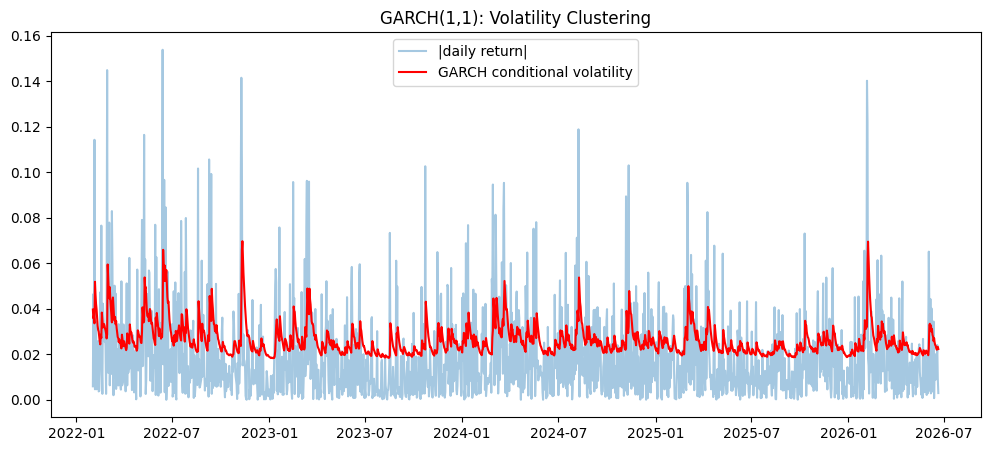

                     Constant Mean - GARCH Model Results                      
Dep. Variable:          market_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3774.73
Distribution:                  Normal   AIC:                           7557.46
Method:            Maximum Likelihood   BIC:                           7578.97
                                        No. Observations:                 1601
Date:                Sat, Jun 20 2026   Df Residuals:                     1600
Time:                        22:31:05   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1288  5.812e-02      2.216  2.667e-02 [1.490e-0

In [10]:
fitted, cond_vol = fit_garch_volatility(df["market_return"])

plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["market_return"].abs(), alpha=0.4, label="|daily return|")
plt.plot(df["timestamp"], cond_vol, color="red", label="GARCH conditional volatility")
plt.legend(); plt.title("GARCH(1,1): Volatility Clustering"); plt.show()

print(fitted.summary())

In [11]:
agent = TradingAgent(target_vol=0.02, max_leverage=1.0)
test_agent = agent.decide(test_gb)        # берём датафрейм с pred и volatility
bt_agent = run_agent_strategy(test_agent)

results["Agent"] = summary(bt_agent["strategy_equity"], bt_agent["strategy_return"])
results

,LogReg,GradBoosting,Buy & Hold (test),ARIMA,Agent
ROI %,-25.93,-61.11,-24.76,-33.23,-34.04
Sharpe,-0.53,-2.02,-0.34,-0.50,-1.75
Sortino,-0.49,-2.09,-0.48,-0.66,-1.26
Calmar,-0.42,-0.74,-0.38,-0.48,-0.65
Max Drawdown %,-48.62,-69.11,-51.16,-55.07,-41.51
Win Rate %,18.58,17.75,49.27,44.05,8.35


In [13]:
bt_ma = run_ma_strategy(df, fee=0.001)

In [14]:
final = pd.DataFrame({
    "Baseline MA":  summary(bt_ma["strategy_equity"], bt_ma["strategy_return"]),
    "ARIMA":        summary(bt_arima["strategy_equity"], bt_arima["strategy_return"]),  # эконометрика
    "LogReg":       summary(bt_lr["strategy_equity"], bt_lr["strategy_return"]),        # ML
    "GradBoosting": summary(bt_gb["strategy_equity"], bt_gb["strategy_return"]),        # ML
    "AI Agent":     summary(bt_agent["strategy_equity"], bt_agent["strategy_return"]),  # агент
    "Buy & Hold":   summary(bt_gb["market_equity"], bt_gb["market_return"]),
})
final

,Baseline MA,ARIMA,LogReg,GradBoosting,AI Agent,Buy & Hold
ROI %,86.13,-33.23,-25.93,-61.11,-34.04,-24.76
Sharpe,0.58,-0.50,-0.53,-2.02,-1.75,-0.34
Sortino,0.66,-0.66,-0.49,-2.09,-1.26,-0.48
Calmar,0.41,-0.48,-0.42,-0.74,-0.65,-0.38
Max Drawdown %,-37.25,-55.07,-48.62,-69.11,-41.51,-51.16
Win Rate %,26.27,44.05,18.58,17.75,8.35,49.27


In [ ]:
from src.backtest import run_ma_rsi_strategy

bt_ma_rsi = run_ma_rsi_strategy(df)

results["MA + RSI filter"] = summary(bt_ma_rsi["strategy_equity"], bt_ma_rsi["strategy_return"])
results